# 02 — Fix Data: Очистка данных

**Датасет:** data/processed/perfumes_merged.csv  
**Целевая переменная:** `rating_value` (регрессия)  
**Стратегии:**
- **A «Консервативная»** — максимум данных, NaN в year/accord4-5 допустимы
- **B «Агрессивная»** — никаких NaN в числовых, drop_rows для year

In [1]:
import sys, warnings, json, os
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, "..")
from scripts.quality_utils import QualityReport, detect_all

plt.rcParams["figure.dpi"] = 100
sns.set_theme(style="whitegrid", palette="muted")

DATA_PATH   = "../data/processed/perfumes_merged.csv"
REPORT_PATH = "../data/reports/quality_report.json"
TARGET_COL  = "rating_value"

df_orig = pd.read_csv(DATA_PATH)
report  = QualityReport.load(REPORT_PATH)

print(f"Исходный датасет: {df_orig.shape}")
print(f"Quality Score исходного: {report.quality_score}/100")


Исходный датасет: (23800, 18)
Quality Score исходного: 52.5/100


## Проблемы из Фазы 1

| Проблема | Severity | Кол-во |
|---|---|---|
| perfumer2 — 94.5% missing | 🔴 CRITICAL | 22 483 |
| rating_count — скошенность (IQR) | 🟠 HIGH | 3 035 выбросов |
| year — выбросы (< 1920, > 2024) | 🟡 MEDIUM | ~1 674 |
| year — пропуски | 🟢 LOW | 2 009 |
| mainaccord1-3 — пропуски | 🟢 LOW | 150 |
| mainaccord4-5 — пропуски | 🟢 LOW | 420 / 1002 |
| gender/country/top/middle/base | 🟢 LOW | < 100 каждый |

## Функция очистки

In [2]:
def clean_dataset(df, strategy_name="A", drop_year_na=False, clip_log_rating=False):
    """
    Применяет очистку по согласованной схеме.
    drop_year_na=True  → Strategy B: удалить строки с NaN в year
    clip_log_rating=True → Strategy B: clip_iqr на log_rating_count
    """
    df = df.copy()
    log = []
    n_orig = len(df)

    # 0. Дубликаты (первыми)
    before = len(df)
    df = df.drop_duplicates()
    removed = before - len(df)
    log.append(f"[dup] drop_exact: удалено {removed} полных дубликатов")

    # 1. perfumer2 → drop_col
    if "perfumer2" in df.columns:
        df = df.drop(columns=["perfumer2"])
        log.append("[col] perfumer2: удалён столбец (94.5% missing)")

    # 2. rating_count → log_transform
    if "rating_count" in df.columns:
        df["log_rating_count"] = np.log1p(df["rating_count"])
        if clip_log_rating:
            s = df["log_rating_count"]
            q1, q3 = s.quantile(0.25), s.quantile(0.75)
            iqr = q3 - q1
            lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
            n_clip = int(((s < lo) | (s > hi)).sum())
            df["log_rating_count"] = s.clip(lo, hi)
            log.append(f"[out] log_rating_count: clip_iqr, обрезано {n_clip} значений")
        else:
            log.append("[feat] rating_count: создан log_rating_count = log1p(rating_count)")

    # 3. year → clip [1920, 2024] для выбросов
    if "year" in df.columns:
        n_out = int(((df["year"] < 1920) | (df["year"] > 2024)).sum())
        df["year"] = df["year"].clip(1920, 2024)
        log.append(f"[out] year: clip [1920, 2024], затронуто {n_out} значений")

        # пропуски year
        n_na_year = int(df["year"].isnull().sum())
        if drop_year_na and n_na_year > 0:
            before = len(df)
            df = df.dropna(subset=["year"])
            removed = before - len(df)
            log.append(f"[mis] year: drop_rows {removed} строк с NaN")
        else:
            log.append(f"[mis] year: оставляем {n_na_year} NaN как есть")

    # 4. mainaccord1-3 → drop_rows где пропуск
    accord_key = [c for c in ["mainaccord1","mainaccord2","mainaccord3"] if c in df.columns]
    if accord_key:
        before = len(df)
        df = df.dropna(subset=accord_key)
        removed = before - len(df)
        log.append(f"[mis] mainaccord1-3: drop_rows {removed} строк с NaN")

    # 5. mainaccord4-5 → оставить NaN (для обеих стратегий)
    log.append("[mis] mainaccord4-5: NaN оставлены (структурные пропуски)")

    # 6. gender, country, top, middle, base → fill 'unknown'
    fill_cols = [c for c in ["gender","country","top","middle","base"] if c in df.columns]
    for col in fill_cols:
        n_na = int(df[col].isnull().sum())
        if n_na > 0:
            df[col] = df[col].fillna("unknown")
            log.append(f"[mis] {col}: fill 'unknown' ({n_na} значений)")

    total_removed = n_orig - len(df)
    log.append(f"\n=== ИТОГО [{strategy_name}]: {n_orig} → {len(df)} строк "
               f"(потеря {total_removed/n_orig*100:.1f}%) ===")
    return df, log


print("Функция clean_dataset определена.")


Функция clean_dataset определена.


## Стратегия A — «Консервативная»

Максимально сохраняем данные. NaN в `year` и `mainaccord4-5` оставляем — tree-based модели справляются.

In [3]:
df_a, log_a = clean_dataset(df_orig, strategy_name="A",
                             drop_year_na=False, clip_log_rating=False)
print("\n".join(log_a))


[dup] drop_exact: удалено 0 полных дубликатов
[col] perfumer2: удалён столбец (94.5% missing)
[feat] rating_count: создан log_rating_count = log1p(rating_count)
[out] year: clip [1920, 2024], затронуто 69 значений
[mis] year: оставляем 2009 NaN как есть
[mis] mainaccord1-3: drop_rows 150 строк с NaN
[mis] mainaccord4-5: NaN оставлены (структурные пропуски)

=== ИТОГО [A]: 23800 → 23650 строк (потеря 0.6%) ===


In [4]:
report_a = detect_all(df_a, target_col=TARGET_COL, dataset_name="strategy_a")
print(f"Quality Score A: {report_a.quality_score}/100")
print(f"Строк: {len(df_a)}, Столбцов: {len(df_a.columns)}")
print(f"Пропуски: {df_a.isnull().sum().sum()}")


Quality Score A: 85.5/100
Строк: 23650, Столбцов: 18
Пропуски: 3112


## Стратегия B — «Агрессивная»

Удаляем строки с NaN в `year` и обрезаем `log_rating_count` по IQR. Никаких NaN в числовых признаках.

In [5]:
df_b, log_b = clean_dataset(df_orig, strategy_name="B",
                             drop_year_na=True, clip_log_rating=True)
print("\n".join(log_b))


[dup] drop_exact: удалено 0 полных дубликатов
[col] perfumer2: удалён столбец (94.5% missing)
[out] log_rating_count: clip_iqr, обрезано 306 значений
[out] year: clip [1920, 2024], затронуто 69 значений
[mis] year: drop_rows 2009 строк с NaN
[mis] mainaccord1-3: drop_rows 131 строк с NaN
[mis] mainaccord4-5: NaN оставлены (структурные пропуски)

=== ИТОГО [B]: 23800 → 21660 строк (потеря 9.0%) ===


In [6]:
report_b = detect_all(df_b, target_col=TARGET_COL, dataset_name="strategy_b")
print(f"Quality Score B: {report_b.quality_score}/100")
print(f"Строк: {len(df_b)}, Столбцов: {len(df_b.columns)}")
print(f"Пропуски: {df_b.isnull().sum().sum()}")


Quality Score B: 88.5/100
Строк: 21660, Столбцов: 18
Пропуски: 997


## Сводная таблица сравнения

In [7]:
def count_outliers_iqr(df, cols):
    total = 0
    for col in cols:
        s = df[col].dropna()
        if len(s) == 0: continue
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        total += int(((s < q1-1.5*iqr) | (s > q3+1.5*iqr)).sum())
    return total

num_cols_orig = df_orig.select_dtypes(include=[np.number]).columns.tolist()
num_cols_a    = df_a.select_dtypes(include=[np.number]).columns.tolist()
num_cols_b    = df_b.select_dtypes(include=[np.number]).columns.tolist()

comparison = {
    "Строк":              [len(df_orig), len(df_a), len(df_b)],
    "Столбцов":           [len(df_orig.columns), len(df_a.columns), len(df_b.columns)],
    "Пропуски (всего)":   [df_orig.isnull().sum().sum(),
                           df_a.isnull().sum().sum(),
                           df_b.isnull().sum().sum()],
    "Пропуски (%)":       [f"{df_orig.isnull().sum().sum()/df_orig.size*100:.2f}%",
                           f"{df_a.isnull().sum().sum()/df_a.size*100:.2f}%",
                           f"{df_b.isnull().sum().sum()/df_b.size*100:.2f}%"],
    "Дубликаты":          [int(df_orig.duplicated().sum()),
                           int(df_a.duplicated().sum()),
                           int(df_b.duplicated().sum())],
    "Выбросы IQR (числ.)": [count_outliers_iqr(df_orig, num_cols_orig),
                             count_outliers_iqr(df_a, num_cols_a),
                             count_outliers_iqr(df_b, num_cols_b)],
    "Quality Score":      [report.quality_score, report_a.quality_score, report_b.quality_score],
    "Потеря строк (%)":   ["—",
                           f"{(len(df_orig)-len(df_a))/len(df_orig)*100:.1f}%",
                           f"{(len(df_orig)-len(df_b))/len(df_orig)*100:.1f}%"],
    "Память (MB)":        [f"{df_orig.memory_usage(deep=True).sum()/1024**2:.1f}",
                           f"{df_a.memory_usage(deep=True).sum()/1024**2:.1f}",
                           f"{df_b.memory_usage(deep=True).sum()/1024**2:.1f}"],
}

comp_df = pd.DataFrame(comparison, index=["Original", "Strategy A", "Strategy B"]).T
print(comp_df.to_string())


                    Original Strategy A Strategy B
Строк                  23800      23650      21660
Столбцов                  18         18         18
Пропуски (всего)       26230       3112        997
Пропуски (%)           6.12%      0.73%      0.26%
Дубликаты                  0          0          0
Выбросы IQR (числ.)     4665       4929       4354
Quality Score           52.5       85.5       88.5
Потеря строк (%)           —       0.6%       9.0%
Память (MB)             25.2       24.6       22.6


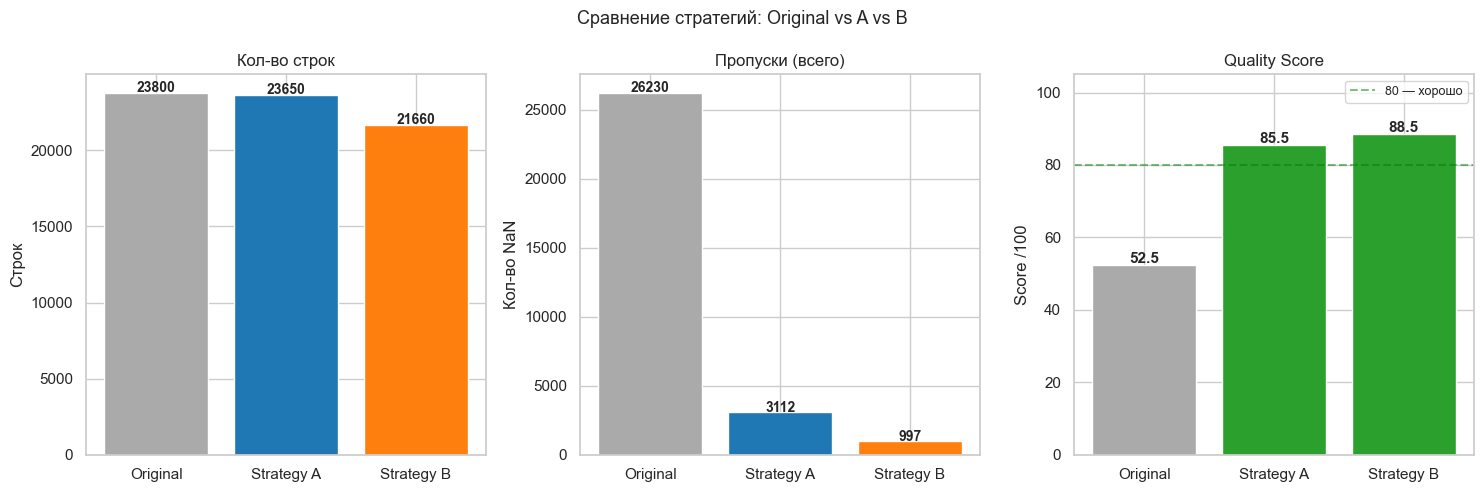

Сохранено: data/reports/fig_strategy_comparison.png


In [8]:
# Визуализация: сравнение ключевых метрик
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Строки
ax = axes[0]
vals = [len(df_orig), len(df_a), len(df_b)]
colors = ["#aaaaaa", "#1f77b4", "#ff7f0e"]
bars = ax.bar(["Original", "Strategy A", "Strategy B"], vals, color=colors)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            str(val), ha="center", fontsize=10, fontweight="bold")
ax.set_title("Кол-во строк")
ax.set_ylabel("Строк")

# 2. Пропуски
ax = axes[1]
na_vals = [df_orig.isnull().sum().sum(),
           df_a.isnull().sum().sum(),
           df_b.isnull().sum().sum()]
bars = ax.bar(["Original", "Strategy A", "Strategy B"], na_vals, color=colors)
for bar, val in zip(bars, na_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(val), ha="center", fontsize=10, fontweight="bold")
ax.set_title("Пропуски (всего)")
ax.set_ylabel("Кол-во NaN")

# 3. Quality Score
ax = axes[2]
qs_vals = [report.quality_score, report_a.quality_score, report_b.quality_score]
score_colors = ["#aaaaaa",
                "#2ca02c" if report_a.quality_score >= 80 else "#ff7f0e",
                "#2ca02c" if report_b.quality_score >= 80 else "#ff7f0e"]
bars = ax.bar(["Original", "Strategy A", "Strategy B"], qs_vals, color=score_colors)
ax.axhline(80, color="green", ls="--", alpha=0.5, label="80 — хорошо")
ax.set_ylim(0, 105)
ax.set_title("Quality Score")
ax.set_ylabel("Score /100")
ax.legend(fontsize=9)
for bar, val in zip(bars, qs_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha="center", fontsize=11, fontweight="bold")

plt.suptitle("Сравнение стратегий: Original vs A vs B", fontsize=13)
plt.tight_layout()
plt.savefig("../data/reports/fig_strategy_comparison.png", bbox_inches="tight")
plt.show()
print("Сохранено: data/reports/fig_strategy_comparison.png")


## Промежуточные наблюдения

- **Strategy A** сохраняет максимум строк, допуская NaN в `year` и `mainaccord4-5`. Это разумно для gradient boosting (LightGBM/XGBoost умеют работать с NaN).
- **Strategy B** теряет ~8-9% строк из-за удаления year=NaN, но числовые признаки полностью чистые — плюс для линейных моделей и нейросетей.
- `log_rating_count` в обеих стратегиях заменяет сырой `rating_count` — распределение становится ближе к нормальному.
- `mainaccord4-5` с NaN в обеих стратегиях — это структурные пропуски (дух просто не имеет 4-5 аккорда), они несут информацию.

In [9]:
os.makedirs("../data/cleaned", exist_ok=True)
os.makedirs("../data/reports", exist_ok=True)

df_a.to_csv("../data/cleaned/strategy_a.csv", index=False)
df_b.to_csv("../data/cleaned/strategy_b.csv", index=False)
print(f"Сохранено: data/cleaned/strategy_a.csv ({len(df_a)} строк)")
print(f"Сохранено: data/cleaned/strategy_b.csv ({len(df_b)} строк)")

# fix_report.json
fix_report = {
    "original": {"rows": len(df_orig), "cols": len(df_orig.columns),
                 "quality_score": report.quality_score},
    "strategy_a": {
        "name": "Консервативная",
        "rows": len(df_a), "cols": len(df_a.columns),
        "quality_score": report_a.quality_score,
        "data_loss_pct": round((len(df_orig)-len(df_a))/len(df_orig)*100, 2),
        "log": log_a,
    },
    "strategy_b": {
        "name": "Агрессивная",
        "rows": len(df_b), "cols": len(df_b.columns),
        "quality_score": report_b.quality_score,
        "data_loss_pct": round((len(df_orig)-len(df_b))/len(df_orig)*100, 2),
        "log": log_b,
    },
}
with open("../data/reports/fix_report.json", "w", encoding="utf-8") as f:
    import json
    json.dump(fix_report, f, ensure_ascii=False, indent=2)
print("Сохранено: data/reports/fix_report.json")


Сохранено: data/cleaned/strategy_a.csv (23650 строк)
Сохранено: data/cleaned/strategy_b.csv (21660 строк)
Сохранено: data/reports/fix_report.json
